# TD1 — Maîtrise Statistique des Processus
## Étude du procédé MECANEX
---

### Contexte

L'entreprise **MECANEX** fabrique une pièce dont la caractéristique de qualité est la **dureté** (HB).

| Paramètre | Valeur |
|---|---|
| Taille de sous-groupe | $n = 5$ pièces consécutives |
| Fréquence | 1 prélèvement par heure |
| Nombre de sous-groupes | $m = 20$ |
| Tolérance inférieure $T_i$ | 262 HB |
| Tolérance supérieure $T_s$ | 302 HB |
| Cible $T$ | 282 HB |

---

### Organisation

> **PARTIE A — Mise en œuvre**
> On applique la méthode telle qu'elle se pratique en atelier : **les constantes $A_3$, $B_3$, $B_4$
> sont lues dans la table normalisée et utilisées telles quelles.** On trace les cartes, on applique
> les règles de Nelson, on interprète, on calcule la capabilité, on conclut.
>
> Deux questions de méthode se posent en chemin — elles sont traitées **avec les seuls chiffres de la
> table**, sans théorie :
> - faut-il centrer la carte $\bar X$ sur $\bar{\bar X}$ ou sur la cible ?
> - comment découper la carte $S$ en zones pour appliquer les règles de Nelson ?
>
> **PARTIE B — D'où viennent ces constantes ?** *(séance suivante)*
> On ouvre la boîte noire : pourquoi $A_3 = 1{,}427$, pourquoi $B_3 = 0$, pourquoi 3 écarts-types,
> et ce que vaut vraiment un $C_{pk}$ estimé sur 100 pièces.

**La partie A se fait intégralement sans la partie B.**

# PARTIE A — MISE EN ŒUVRE

## A.0 — Données et table des constantes

In [276]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.lib.stride_tricks import sliding_window_view as fenetres

plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

# =====================================================================
#  TABLE DES CONSTANTES DE CARTES DE CONTROLE  (extrait d'ISO 7870-2)
#  On les utilise ICI telles quelles. Leur origine : partie B.
#      n  :  (c4,     A3,    B3,    B4)
# =====================================================================
TABLE = {
    2:  (0.7979, 2.659, 0.000, 3.267),
    3:  (0.8862, 1.954, 0.000, 2.568),
    4:  (0.9213, 1.628, 0.000, 2.266),
    5:  (0.9400, 1.427, 0.000, 2.089),
    6:  (0.9515, 1.287, 0.030, 1.970),
    7:  (0.9594, 1.182, 0.118, 1.882),
    8:  (0.9650, 1.099, 0.185, 1.815),
    9:  (0.9693, 1.032, 0.239, 1.761),
    10: (0.9727, 0.975, 0.284, 1.716),
}

print("Table des constantes (ISO 7870-2)\n")
print(f"{'n':>3}{'c4':>9}{'A3':>8}{'B3':>8}{'B4':>8}")
for nn, (c, a, b3, b4) in TABLE.items():
    print(f"{nn:>3}{c:>9.4f}{a:>8.3f}{b3:>8.3f}{b4:>8.3f}")

Table des constantes (ISO 7870-2)

  n       c4      A3      B3      B4
  2   0.7979   2.659   0.000   3.267
  3   0.8862   1.954   0.000   2.568
  4   0.9213   1.628   0.000   2.266
  5   0.9400   1.427   0.000   2.089
  6   0.9515   1.287   0.030   1.970
  7   0.9594   1.182   0.118   1.882
  8   0.9650   1.099   0.185   1.815
  9   0.9693   1.032   0.239   1.761
 10   0.9727   0.975   0.284   1.716


---

## A.1 — Statistiques par sous-groupe

> **Q1.**  
> - Importer les données du fichier *`data.dat`* dans un tableau *`Numpy`*
> - Calculer, pour chaque sous-groupe $j$, la moyenne $\bar X_j$ et l'écart-type $S_j$.
> - En déduire $\bar{\bar X}$ (moyenne des moyennes) et $\bar S$ (moyenne des écarts-types).
> - Afficher les variables calculées (*`print`*)  
> - Interpréter les valeurs obtenues pour $\bar{\bar X}$ et $\bar S$, que peut on conclure et ne pas conclure ?

> ### ⚠️ Attention au diviseur
>
> $$S_j = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\big(X_{ij}-\bar X_j\big)^2}$$
>
> En Python : `np.std(..., ddof=1)`. En Excel : `ECARTYPE.STANDARD`, **pas** `ECARTYPE.PEARSON`.
>
> **Les constantes de la table sont définies pour cet estimateur-là.** Les utiliser avec un $S$ calculé
> en $1/n$ donnerait des limites fausses.

> **Q1.**  
> - Importation des données du fichier *`data.dat`* dans un tableau *`Numpy`*
> - Affichage des données (nombre éch., taille éch., tolérences, cible, constantes)

In [277]:
import os
FICHIER = 'data.dat'

if os.path.exists(FICHIER):
    data = np.loadtxt(FICHIER)
    print(f"Donnees chargees depuis '{FICHIER}'")
else:
    print("!" * 76)
    print("'data.dat' introuvable -> JEU DE SUBSTITUTION utilise.")
    print("Les valeurs numeriques ci-dessous ne sont pas celles du sujet.")
    print("!" * 76)
    data = np.array([
        [272.8, 281.7, 288.6, 281.1, 264.9], [270.1, 263.5, 274.4, 273.9, 277.4],
        [273.8, 269.7, 283.7, 271.4, 281.5], [265.2, 266.7, 276.5, 275.1, 271.9],
        [284.2, 274.3, 284.1, 274.5, 272.0], [287.5, 279.4, 287.6, 271.6, 273.9],
        [282.9, 278.5, 280.0, 276.3, 282.6], [276.0, 277.1, 272.9, 280.8, 268.0],
        [278.5, 281.3, 272.8, 277.0, 279.3], [276.7, 277.2, 279.9, 284.3, 283.9],
        [282.4, 281.5, 283.3, 282.4, 281.7], [284.5, 280.6, 286.5, 283.1, 279.6],
        [279.0, 275.4, 283.4, 283.7, 287.7], [280.0, 280.7, 284.7, 280.4, 275.7],
        [278.9, 287.6, 283.1, 284.3, 288.0], [284.1, 268.9, 273.3, 285.2, 277.0],
        [276.1, 282.9, 286.0, 286.5, 286.5], [286.3, 288.0, 281.5, 291.2, 286.5],
        [285.9, 287.2, 283.5, 281.5, 285.6], [288.2, 284.3, 288.1, 283.5, 285.5]])

m, n = data.shape
Ti, Ts, CIBLE = 262.0, 302.0, 282.0
IT = Ts - Ti

c4n, A3, B3, B4 = TABLE[n]          # <- les 4 constantes dont on aura besoin

print(f"\nm = {m} sous-groupes de n = {n} pieces ({data.size} mesures)")
print(f"Tolerances [{Ti} ; {Ts}], IT = {IT} HB, cible = {CIBLE} HB")
print(f"\nConstantes retenues pour n = {n} :  c4 = {c4n}   A3 = {A3}   B3 = {B3}   B4 = {B4}")

Donnees chargees depuis 'data.dat'

m = 20 sous-groupes de n = 5 pieces (100 mesures)
Tolerances [262.0 ; 302.0], IT = 40.0 HB, cible = 282.0 HB

Constantes retenues pour n = 5 :  c4 = 0.94   A3 = 1.427   B3 = 0.0   B4 = 2.089


## A.1 — Statistiques par sous-groupe

> **Q1.**  
> - Calcul de la moyenne $\bar X_j$ et de l'écart-type $S_j$.
> - Calcul de $\bar{\bar X}$ (moyenne des moyennes) et $\bar S$ (moyenne des écarts-types).
> - Affichage des variables calculées

In [278]:
Xbar = data.mean(axis=1)            # m moyennes de sous-groupe
S    = data.std(axis=1, ddof=1)     # m ecarts-types de sous-groupe
R    = data.max(axis=1) - data.min(axis=1)

Xbb  = Xbar.mean()                  # X double barre : UNE valeur
Sbar = S.mean()                     # S barre        : UNE valeur

print(f"{'j':>3}{'X-barre_j':>12}{'S_j':>10}{'R_j':>8}")
for j in range(m):
    print(f"{j+1:>3}{Xbar[j]:>12.2f}{S[j]:>10.2f}{R[j]:>8.2f}")
print("-" * 33)
print(f"{'':3}{Xbb:>12.3f}{Sbar:>10.3f}{R.mean():>8.2f}   <- X== et S-barre")
print(f"\nDecentrage par rapport a la cible : {Xbb - CIBLE:+.2f} HB")

  j   X-barre_j       S_j     R_j
  1      273.80      4.38    8.00
  2      277.00      8.00   16.00
  3      277.00      9.80   24.00
  4      275.40      6.69   16.00
  5      281.80      7.16   16.00
  6      278.60      8.76   16.00
  7      281.80      4.38    8.00
  8      278.60      6.69   16.00
  9      280.20      4.38    8.00
 10      281.80      4.38    8.00
 11      281.40      4.10    8.00
 12      281.00      4.00    8.00
 13      281.80      4.38    8.00
 14      277.00      5.66   16.00
 15      283.40      6.69   16.00
 16      278.80      5.76   14.00
 17      280.00      3.61   10.00
 18      281.40      5.41   13.00
 19      282.40      8.17   21.00
 20      284.40      1.95    5.00
---------------------------------
        279.880     5.718   12.75   <- X== et S-barre

Decentrage par rapport a la cible : -2.12 HB


> ### ✅ Réponse Q1
>
> $$\bar{\bar X} = 279{,}88 \text{ HB} \qquad \bar S = 5{,}718 \text{ HB}$$
>
> Le procédé tourne **2,12 HB en dessous de la cible**. À ce stade, on ne sait pas encore si c'est un décentrage installé ou le résultat d'une dérive : les cartes vont le dire.

---

## A.2 — La carte à la moyenne

**Formules à appliquer** *(constantes lues dans la table)* :

$$\text{LSC} = \text{LC} + A_3\,\bar S \qquad\qquad \text{LIC} = \text{LC} - A_3\,\bar S$$

où LC est la ligne centrale. Avec $n=5$ : $A_3 = 1{,}427$.

> **Q2.**  
> - Calculer les limites avec $\bar{\bar X}$ comme ligne centrale puis avec la cible comme ligne centrale
> - tracer la carte $\bar X$, avec $\bar{\bar X}$ comme ligne centrale puis avec la cible comme ligne centrale
> - Découper les cartes en 6 zones égales

> ### Le découpage en zones
>
> Les règles de Nelson (§A.4) exigent un découpage de la carte en zones **A**, **B** et **C**, de
> largeur égale au tiers de la distance entre la ligne centrale et la limite :
>
> ```
>    LSC  ────────────────────
>          zone A
>         ────────────────────
>          zone B
>         ────────────────────
>          zone C
>    LC   ════════════════════
>          zone C
>         ────────────────────
>          ...
> ```
>
> Pour la carte $\bar X$, aucune difficulté : la carte est **symétrique** autour de la ligne centrale,
> et les six zones ont exactement la même largeur, $A_3\bar S/3$.
>
> *(On verra en §A.3 que la carte $S$ ne se laisse pas faire aussi facilement.)*

In [279]:
def carte_controle(valeurs, ligne_centrale, sigma_stat, titre, ylabel,
                   lic=None, lsc=None, ax=None, cible=None):
    """Carte de Shewhart avec ses zones A / B / C.

    sigma_stat : largeur d'une zone, c'est-a-dire le tiers de la distance
                 entre la ligne centrale et la limite superieure.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(1, len(valeurs) + 1)
    lsc = ligne_centrale + 3 * sigma_stat if lsc is None else lsc
    lic = ligne_centrale - 3 * sigma_stat if lic is None else lic

    for k, al in [(1, 0.16), (2, 0.10), (3, 0.05)]:          # zones C, B, A
        ax.axhspan(max(ligne_centrale - k*sigma_stat, lic),
                   min(ligne_centrale + k*sigma_stat, lsc),
                   color='steelblue', alpha=al, zorder=0)
    for k in (1, 2):
        for y in (ligne_centrale + k*sigma_stat, ligne_centrale - k*sigma_stat):
            if lic <= y <= lsc:
                ax.axhline(y, color='grey', ls=':', lw=1, zorder=1)

    ax.axhline(ligne_centrale, color='green', lw=1.8, label=f'LC = {ligne_centrale:.2f}')
    ax.axhline(lsc, color='red', lw=1.8, label=f'LSC = {lsc:.2f}')
    ax.axhline(lic, color='red', lw=1.8, label=f'LIC = {lic:.2f}')
    if cible is not None:
        ax.axhline(cible, color='darkorange', ls='--', lw=1.5, label=f'Cible = {cible:.1f}')
    ax.plot(x, valeurs, 'o-', color='navy', ms=6, lw=1.4, zorder=3)
    ax.set(title=titre, xlabel="n° de sous-groupe", ylabel=ylabel)
    ax.set_xticks(x); ax.legend(loc='upper left', fontsize=9, ncol=2)
    return ax

# --- Limites de la carte Xbar ---
demi_Xbar   = A3 * Sbar          # demi-largeur
zone_Xbar   = demi_Xbar / 3      # largeur d'une zone (= 1 "ecart-type de carte")

print(f"Demi-largeur = A3 x S-barre = {A3} x {Sbar:.4f} = {demi_Xbar:.4f} HB")
print(f"Largeur d'une zone          = {demi_Xbar:.4f} / 3 = {zone_Xbar:.4f} HB\n")
print(f"  LC  = X== = {Xbb:.2f}")
print(f"  LSC = {Xbb + demi_Xbar:.2f}")
print(f"  LIC = {Xbb - demi_Xbar:.2f}")

Demi-largeur = A3 x S-barre = 1.427 x 5.7182 = 8.1599 HB
Largeur d'une zone          = 8.1599 / 3 = 2.7200 HB

  LC  = X== = 279.88
  LSC = 288.04
  LIC = 271.72


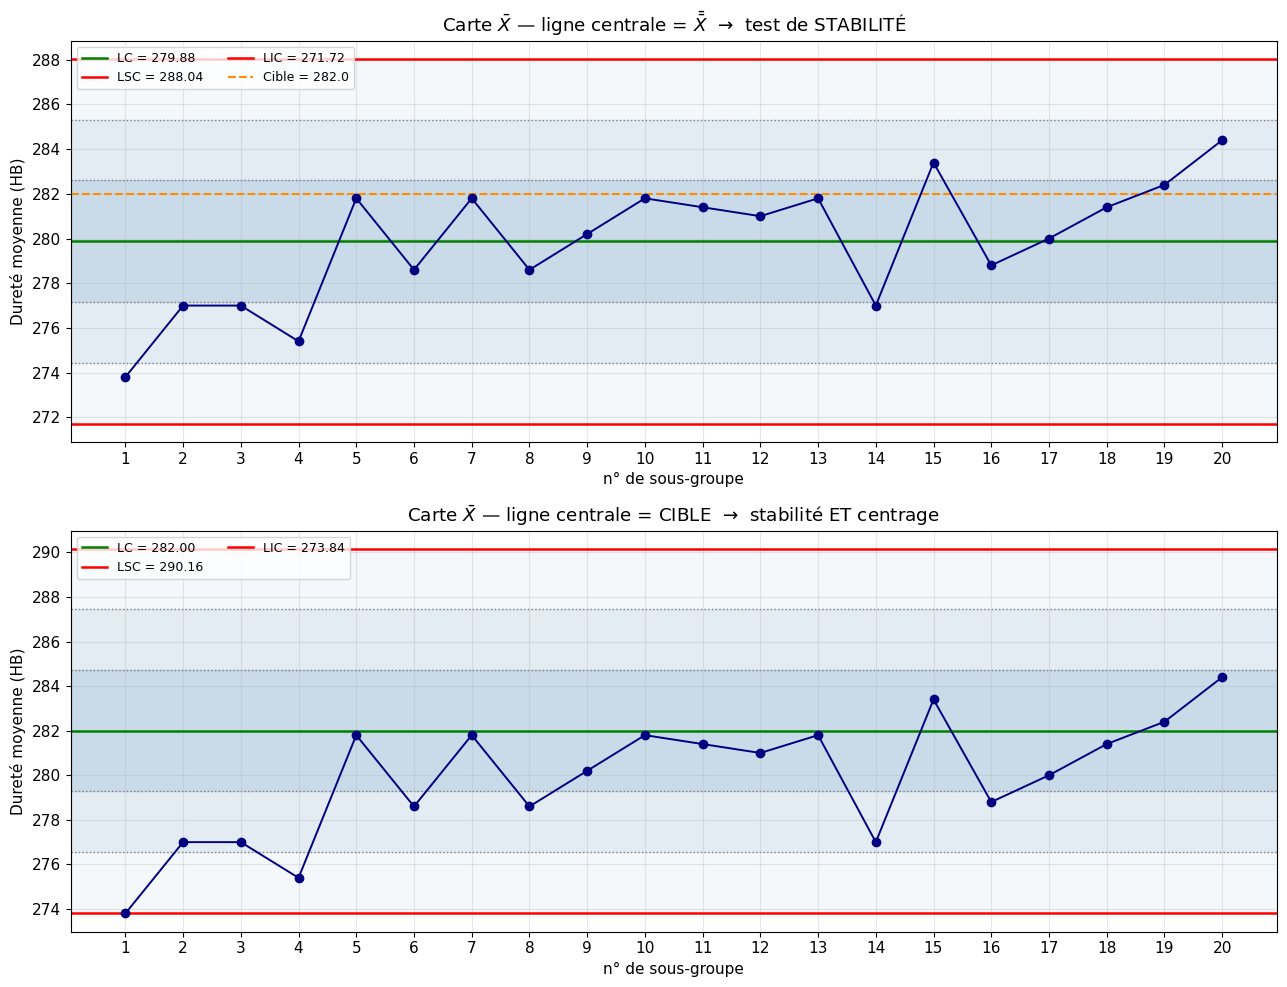

Limites autour de X== = 279.88 : [271.72 ; 288.04]
Limites autour de la cible = 282 : [273.84 ; 290.16]

Decalage entre les deux jeux de limites : +2.12 HB


In [280]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

carte_controle(Xbar, Xbb, zone_Xbar,
               r"Carte $\bar{X}$ — ligne centrale = $\bar{\bar{X}}$  →  test de STABILITÉ",
               "Dureté moyenne (HB)", ax=axes[0], cible=CIBLE)

carte_controle(Xbar, CIBLE, zone_Xbar,
               r"Carte $\bar{X}$ — ligne centrale = CIBLE  →  stabilité ET centrage",
               "Dureté moyenne (HB)", ax=axes[1])

plt.tight_layout(); plt.show()

print(f"Limites autour de X== = {Xbb:.2f} : [{Xbb-demi_Xbar:.2f} ; {Xbb+demi_Xbar:.2f}]")
print(f"Limites autour de la cible = {CIBLE:.0f} : [{CIBLE-demi_Xbar:.2f} ; {CIBLE+demi_Xbar:.2f}]")
print(f"\nDecalage entre les deux jeux de limites : {CIBLE-Xbb:+.2f} HB")

> **Q3.**  
> - Charger les règles de Nelson
> - Appliquer le test aux 2 cartes de contrôle
> - Afficher les résultats dans un tableau pour chacune des règles en indiquant à quels points se déclenchent les alarmes

In [281]:
REGLES = {
    1: "1 point au-dela de 3 zones (hors limites)",
    2: "9 points consecutifs du meme cote de la LC",
    3: "6 points consecutifs croissants ou decroissants",
    4: "14 points consecutifs en alternance",
    5: "2 points sur 3 au-dela de 2 zones, meme cote",
    6: "4 points sur 5 au-dela de 1 zone, meme cote",
    7: "15 points consecutifs a moins de 1 zone de la LC",
    8: "8 points consecutifs a plus de 1 zone de la LC",
}

def nelson(valeurs, ligne_centrale, zone, regles=(1,2,3,4,5,6,7,8)):
    """Applique les regles de Nelson.
    zone = largeur d'une zone. Renvoie {n_regle: [indices 1-based des alarmes]}.
    Convention : une regle sur une fenetre de k points signale le DERNIER point."""
    Z = (np.asarray(valeurs, float) - ligne_centrale) / zone
    T = len(Z); res = {}
    poser = lambda masque, k: (np.where(masque)[0] + k).tolist()

    if 1 in regles:
        res[1] = (np.where(np.abs(Z) > 3)[0] + 1).tolist()
    if 2 in regles and T >= 9:
        w = fenetres(np.sign(Z), 9); res[2] = poser((w.sum(1) == 9) | (w.sum(1) == -9), 9)
    if 3 in regles and T >= 6:
        d = np.sign(np.diff(Z)); w = fenetres(d, 5)
        res[3] = poser((w.sum(1) == 5) | (w.sum(1) == -5), 6)
    if 4 in regles and T >= 14:
        d = np.sign(np.diff(Z)); alt = (d[:-1]*d[1:]) == -1
        res[4] = poser(fenetres(alt, 12).all(1), 14)
    if 5 in regles and T >= 3:
        w = fenetres(Z, 3); res[5] = poser(((w > 2).sum(1) >= 2) | ((w < -2).sum(1) >= 2), 3)
    if 6 in regles and T >= 5:
        w = fenetres(Z, 5); res[6] = poser(((w > 1).sum(1) >= 4) | ((w < -1).sum(1) >= 4), 5)
    if 7 in regles and T >= 15:
        res[7] = poser(fenetres(np.abs(Z) < 1, 15).all(1), 15)
    if 8 in regles and T >= 8:
        res[8] = poser(fenetres(np.abs(Z) > 1, 8).all(1), 8)
    return {k: v for k, v in res.items() if v}

def rapport(nom, valeurs, lc, zone):
    print(f"\n{'='*72}\n  {nom}\n{'='*72}")
    al = nelson(valeurs, lc, zone)
    if not al:
        print("  Aucune alarme : rien ne contredit l'hypothese de controle statistique.")
    for k in sorted(al):
        print(f"  Regle {k} — {REGLES[k]}\n            points : {al[k]}")
    return al

al_Xbb   = rapport("CARTE Xbar — LC = X== (stabilite seule)",        Xbar, Xbb,   zone_Xbar)
al_cible = rapport("CARTE Xbar — LC = CIBLE (stabilite ET centrage)", Xbar, CIBLE, zone_Xbar)


  CARTE Xbar — LC = X== (stabilite seule)
  Regle 6 — 4 points sur 5 au-dela de 1 zone, meme cote
            points : [5]

  CARTE Xbar — LC = CIBLE (stabilite ET centrage)
  Regle 1 — 1 point au-dela de 3 zones (hors limites)
            points : [1]
  Regle 2 — 9 points consecutifs du meme cote de la LC
            points : [9, 10, 11, 12, 13, 14]
  Regle 6 — 4 points sur 5 au-dela de 1 zone, meme cote
            points : [5, 6]


> **Q4.**  
> - Comparer les différences obtenues (test de Nelson) sur les 2 cartes
> - Quelle interprétation peut on faire pour chacune des cartes

> ### ✅ Réponse Q4
>
> **Les deux cartes ont la même largeur** ($\pm 6{,}27$ HB) : seule la position change, décalée de
> 2,1 HB.
>
> **Conséquence pratique.** Le nuage de points étant globalement sous la cible, la seconde carte
> déclenche des alarmes que la première ne voit pas — en particulier les règles de suite (points du
> même côté de la ligne centrale).
>
> **Comment lire cette différence :**
>
> | Situation | Diagnostic | Action |
> |---|---|---|
> | Alarme sur les **deux** cartes | Instabilité réelle | Rechercher la cause spéciale |
> | Alarme **seulement** sur la carte-cible | **Décentrage** sans instabilité | **Régler** la machine |
> | Aucune alarme | Procédé stable et centré | Ne rien faire |
>
> **Ce sont deux problèmes différents, qui appellent deux actions différentes.** Un décentrage ne se
> résout pas en cherchant une cause spéciale : il se résout au réglage.
>
> **Recommandation pour la suite du TD :** on garde $\bar{\bar X}$ pour juger la **stabilité** (c'est
> la question posée par la MSP), et on traite le décentrage séparément, dans l'étude de capabilité
> (§A.5), où il est mesuré par l'écart entre $C_p$ et $C_{pk}$.

### 💬 Discussion 1 — Ligne centrale : $\bar{\bar X}$ ou la cible ?

Les deux pratiques existent. Le choix **change la question que pose la carte**.

| | Ligne centrale $= \bar{\bar X}$ | Ligne centrale $= T$ (cible) |
|---|---|---|
| **Question posée** | Le procédé est-il **stable** ? | Est-il **stable ET centré** ? |
| **Ce qui déclenche une alarme** | Les écarts à son **propre** niveau moyen | En plus : le décentrage permanent |
| **Risque** | Un décentrage installé dès le départ est **intégré comme normal** et devient invisible | Alarmes persistantes tant que le réglage n'est pas fait |
| **Nature de la carte** | Contrôle **statistique** (esprit Shewhart) | **Pilotage / conformité** |

> **Ni l'un ni l'autre n'est « la bonne réponse ».** Ce qui compte est de savoir ce qu'on teste.

---

## A.3 — La carte à l'écart-type

> **Pourquoi une deuxième carte ?** Les limites de la carte $\bar X$ sont calculées à partir de
> $\bar S$. Si la dispersion du procédé change, ces limites deviennent fausses — sans que la carte
> $\bar X$ ne le signale nécessairement. **Une carte $\bar X$ sans carte de dispersion est
> inexploitable.**

**Formules à appliquer :**

$$\text{LIC}_S = B_3\,\bar S \qquad\qquad \text{LC}_S = \bar S \qquad\qquad \text{LSC}_S = B_4\,\bar S$$

Avec $n=5$ : $B_3 = 0$ et $B_4 = 2{,}089$.

> **Q5.** 
> - Calculer les limites de la carte $\bar S$. Que constatez-vous sur la limite inférieure ?

In [282]:
lic_S = B3 * Sbar
lsc_S = B4 * Sbar

print(f"  LIC_S = B3 x S-barre = {B3} x {Sbar:.4f} = {lic_S:.4f} HB")
print(f"  LC_S  =      S-barre =                    {Sbar:.4f} HB")
print(f"  LSC_S = B4 x S-barre = {B4} x {Sbar:.4f} = {lsc_S:.4f} HB")

print("\n--- Valeurs de B3 dans la table ---")
for nn, (_, _, b3, b4) in TABLE.items():
    print(f"   n = {nn:>2} :  B3 = {b3:.3f}" + ("   <- nulle" if b3 == 0 else ""))

  LIC_S = B3 x S-barre = 0.0 x 5.7182 = 0.0000 HB
  LC_S  =      S-barre =                    5.7182 HB
  LSC_S = B4 x S-barre = 2.089 x 5.7182 = 11.9453 HB

--- Valeurs de B3 dans la table ---
   n =  2 :  B3 = 0.000   <- nulle
   n =  3 :  B3 = 0.000   <- nulle
   n =  4 :  B3 = 0.000   <- nulle
   n =  5 :  B3 = 0.000   <- nulle
   n =  6 :  B3 = 0.030
   n =  7 :  B3 = 0.118
   n =  8 :  B3 = 0.185
   n =  9 :  B3 = 0.239
   n = 10 :  B3 = 0.284


> ### ✅ Réponse Q5 — la carte $S$ n'a pas de limite inférieure
>
> **$B_3 = 0$ pour $n \le 5$.** La limite inférieure est donc confondue avec l'axe : **aucun point ne
> pourra jamais tomber en dessous.**
>
> **Conséquence opérationnelle, et elle est lourde :**
>
> $$\boxed{\text{Avec } n \le 5, \text{ la carte } S \text{ ne peut pas détecter une BAISSE de la variabilité.}}$$
>
> **Autrement dit, elle ne peut pas servir à valider une amélioration.** Si vous menez un chantier
> d'amélioration continue et divisez la dispersion par deux, votre carte $S$ à $n=5$ ne dira **rien**.
>
> **C'est un argument technique en faveur de $n \geq 6$** dès que l'objectif est de démontrer un gain :
> la table donne $B_3 = 0{,}030$ à $n=6$ et $B_3 = 0{,}284$ à $n=10$ — la limite basse existe alors
> réellement.
>
> *(Pourquoi $B_3$ est-il nul ? Voir §B.3.)*

### 💬 Discussion — Comment découper la carte $S$ en zones ?

Pour appliquer les règles de Nelson à la carte $S$, il faut, comme pour la carte $\bar X$, la découper
en zones A / B / C.

**Deux méthodes viennent naturellement à l'esprit.**

**Méthode 1 — découper l'intervalle entre les limites en 6 parts égales.**
C'est ce qu'on a fait pour la carte $\bar X$, et cela semble se transposer directement :
$$\text{largeur d'une zone} = \frac{\text{LSC}_S - \text{LIC}_S}{6} = \frac{(B_4-B_3)\,\bar S}{6}$$

**Méthode 2 — partir de la ligne centrale.**
Une zone fait, par définition, le tiers de la distance entre la ligne centrale et la limite. Comme la
limite **supérieure** n'a pas été touchée par la troncature, on peut s'appuyer dessus :
$$\text{largeur d'une zone} = \frac{\text{LSC}_S - \text{LC}_S}{3} = \frac{(B_4-1)\,\bar S}{3}$$



> **Q6.**  
> - Est ce que l'on obtient le même zonage avec les 2 méthodes ?
> - Quel est le critère à respecter afin que les 2 méthodes donnent le même résultat ?
> - Observe t-on le même problème pour la carte à la moyenne ?

> **Ces deux méthodes donnent-elles la même chose ?** -- Non
>
> Elles coïncident si et seulement si la ligne centrale tombe **au milieu** de l'intervalle, c'est-à-dire si
> $$\frac{B_3+B_4}{2} = 1 \qquad\Longleftrightarrow\qquad \boxed{B_3 + B_4 = 2}$$
>
> **Ce critère se vérifie directement dans la table.** Aucune théorie n'est nécessaire.
> 
> On n'observe pas la même chose pour la carte à la moyenne car elle est "symétrique"

In [283]:
print("Le critere de symetrie, lu directement dans la table :\n")
print(f"{'n':>3}{'B3':>8}{'B4':>8}{'B3+B4':>9}{'':>6}{'milieu = (B3+B4)/2':>20}")
for nn, (_, _, b3, b4) in TABLE.items():
    sym = "symetrique" if abs(b3 + b4 - 2) < 1e-9 else "PAS symetrique"
    print(f"{nn:>3}{b3:>8.3f}{b4:>8.3f}{b3+b4:>9.3f}{'':>6}{(b3+b4)/2:>10.3f}   {sym}")

# --- Comparaison chiffree des deux methodes, pour n = 5 ---
zone_m1 = (lsc_S - lic_S) / 6          # methode 1 : decoupage en 6
zone_m2 = (lsc_S - Sbar)  / 3          # methode 2 : depuis la ligne centrale

print(f"\n\nLargeur d'une zone, n = {n} :")
print(f"   methode 1 (decoupage en 6)       : ({lsc_S:.4f} - {lic_S:.4f}) / 6 = {zone_m1:.4f} HB")
print(f"   methode 2 (depuis la LC)         : ({lsc_S:.4f} - {Sbar:.4f}) / 3 = {zone_m2:.4f} HB")

print(f"\nFrontieres de zones (HB) :\n")
print(f"  {'':>16}{'METHODE 2':>12}{'methode 1':>14}{'ecart':>10}")
for k, lab in [(-2, '-2 zones'), (-1, '-1 zone'), (0, 'LIGNE CENTRALE'),
               (1, '+1 zone'), (2, '+2 zones')]:
    z2 = Sbar + k * zone_m2
    z1 = lic_S + (k + 3) * zone_m1
    e  = f"{100*(z1-z2)/z2:+.0f} %" if z2 > 1e-9 else "   -"
    print(f"  {lab:>16}{z2:>12.4f}{z1:>14.4f}{e:>10}")

Le critere de symetrie, lu directement dans la table :

  n      B3      B4    B3+B4        milieu = (B3+B4)/2
  2   0.000   3.267    3.267           1.633   PAS symetrique
  3   0.000   2.568    2.568           1.284   PAS symetrique
  4   0.000   2.266    2.266           1.133   PAS symetrique
  5   0.000   2.089    2.089           1.044   PAS symetrique
  6   0.030   1.970    2.000           1.000   symetrique
  7   0.118   1.882    2.000           1.000   symetrique
  8   0.185   1.815    2.000           1.000   symetrique
  9   0.239   1.761    2.000           1.000   symetrique
 10   0.284   1.716    2.000           1.000   symetrique


Largeur d'une zone, n = 5 :
   methode 1 (decoupage en 6)       : (11.9453 - 0.0000) / 6 = 1.9909 HB
   methode 2 (depuis la LC)         : (11.9453 - 5.7182) / 3 = 2.0757 HB

Frontieres de zones (HB) :

                     METHODE 2     methode 1     ecart
          -2 zones      1.5668        1.9909     +27 %
           -1 zone      3.6425      

> ### ✅ Réponse Q6
>
> **La colonne $B_3 + B_4$ tranche la question sans aucun calcul théorique :**
>
> | $n$ | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
> |---|---|---|---|---|---|---|---|---|---|
> | $B_3+B_4$ | 3,267 | 2,568 | 2,266 | **2,089** | **2,000** | **2,000** | **2,000** | **2,000** | **2,000** |
>
> **À partir de $n=6$, la somme vaut exactement 2** : la ligne centrale est au milieu, la carte est
> symétrique, et **les deux méthodes donnent le même résultat**.
>
> **En dessous, la somme dépasse 2** : la ligne centrale n'est **pas** au milieu, et la méthode 1 est
> fausse. L'écart grandit quand $n$ diminue — de 4 % à $n=5$ jusqu'à 63 % à $n=2$.
>
> **La cause est visible dans la table :** $B_3$ vaut exactement 0 pour $n \le 5$. Ce zéro n'est pas une
> valeur calculée, c'est un **plancher** : la formule donnerait une valeur négative, impossible pour un
> écart-type. La moitié basse de l'intervalle a donc été amputée, ce qui déplace son milieu vers le haut.
>
> ### Et l'erreur n'est pas uniforme sur la carte
>
> | Zone | Écart méthode 1 / méthode 2 |
> |---|---|
> | $+2$ zones | +1 % |
> | Ligne centrale | +4 % |
> | $-1$ zone | +9 % |
> | **$-2$ zones** | **+27 %** |
>
> **C'est gênant, parce que la frontière à 2 zones est précisément celle qu'utilisent les règles 5 et 6
> de Nelson** (« 2 points sur 3 au-delà de 2 zones »). L'erreur est concentrée là où elle produit le
> plus de fausses alarmes.
>
> ### 🎯 La règle à retenir
>
> **Ne construisez jamais des zones en découpant l'intervalle entre les limites.** Partez toujours de
> la ligne centrale : c'est aussi simple, et cela reste juste quand la carte n'est pas symétrique —
> carte $S$, carte $R$, cartes d'attributs ($p$, $c$, $u$), toutes concernées.
>
> **Le test $B_3 + B_4 = 2$ vous dit en une seconde si la carte est symétrique.**

> **Q7.**  
> - Tracer la carte $S$ avec les zones construites correctement.
> - Appliquer le test de Nelson -- Interpréter la carte 

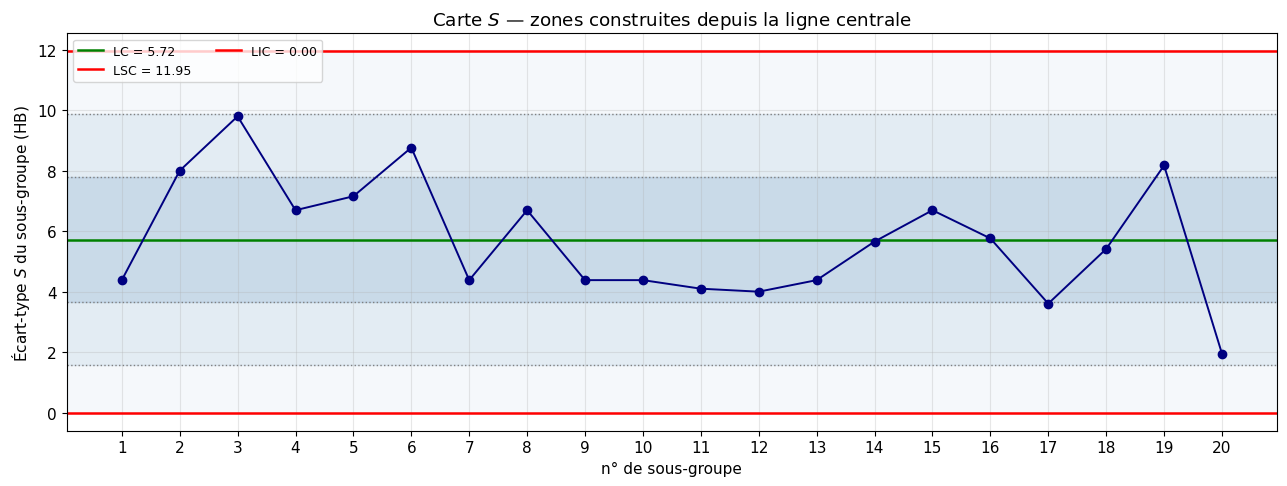

LIC_S = 0.000   (pas de limite basse utilisable : B3 = 0)
LC_S  = 5.718
LSC_S = 11.945
Largeur d'une zone = 2.076 HB


In [284]:
fig, ax = plt.subplots(figsize=(13, 5))
carte_controle(S, Sbar, zone_m2, lic=lic_S, lsc=lsc_S,
               titre=r"Carte $S$ — zones construites depuis la ligne centrale",
               ylabel="Écart-type $S$ du sous-groupe (HB)", ax=ax)
plt.tight_layout(); plt.show()

print(f"LIC_S = {lic_S:.3f}   (pas de limite basse utilisable : B3 = 0)")
print(f"LC_S  = {Sbar:.3f}")
print(f"LSC_S = {lsc_S:.3f}")
print(f"Largeur d'une zone = {zone_m2:.3f} HB")

In [285]:
al_S     = rapport("CARTE S — LC = S-barre", S, Sbar, zone_m2)


  CARTE S — LC = S-barre
  Aucune alarme : rien ne contredit l'hypothese de controle statistique.


> ### ✅ Réponse Q7
>
> **Trois observations, à croiser.**
>
> **1. La carte $\bar X$ centrée sur $\bar{\bar X}$ signale des alarmes.** Il y a donc une
> **instabilité réelle**, indépendamment de toute question de centrage.
>
> **2. La carte centrée sur la cible en signale davantage**, dont des règles de suite. C'est la
> signature du **décentrage** de 2,1 HB identifié en Q1 : des points durablement du même côté de la
> cible.
>
> **3. La carte $S$ ne signale rien.** **La dispersion est stable.**
>
> ### Diagnostic d'ensemble
>
> $$\boxed{\text{Dispersion maîtrisée, moyenne instable et décentrée.}}$$
>
> C'est un diagnostic **utile** : il oriente la recherche vers tout ce qui déplace le niveau du procédé
> (réglage, lot matière, outil, opérateur) et **exclut** tout ce qui affecterait sa régularité (jeu
> mécanique, usure d'un guidage, instabilité de la mesure).

---

## A.4 — Étude de capabilité

> ### ⚠️ L'ordre est contraignant
>
> $$\text{Stabilité} \;\longrightarrow\; \text{Capabilité}$$
>
> **Un indice de capabilité calculé sur un procédé hors contrôle n'a aucun sens.** Il estime les
> paramètres d'une loi qui, par définition, n'est pas stable : le nombre obtenu est bien défini
> arithmétiquement, mais il **ne prédit rien**.
>
> Nous allons quand même le calculer — **précisément pour montrer ce qui cloche**.

### Les formules

Il faut d'abord une estimation de $\sigma$, l'écart-type des **pièces individuelles**. La table fournit
pour cela le coefficient $c_4$ :

$$\hat\sigma_{\text{court terme}} = \frac{\bar S}{c_4} \qquad (c_4 = 0{,}9400 \text{ pour } n=5)$$

*(Pourquoi diviser par $c_4$ ? Voir §B.2. Pour l'instant, on applique la recette.)*

$$C_p = \frac{T_s-T_i}{6\hat\sigma} \qquad\qquad C_{pk} = \min\left(\frac{T_s-\bar{\bar X}}{3\hat\sigma},\ \frac{\bar{\bar X}-T_i}{3\hat\sigma}\right)$$

> **Image.** $C_p$ compare la largeur de la voiture à celle du garage. $C_{pk}$ tient compte de ce que
> la voiture est garée de travers. On a toujours $C_{pk} \le C_p$, avec égalité si le procédé est centré.

Les indices **$P_p$ et $P_{pk}$** utilisent la même formule, mais avec l'écart-type calculé sur
**l'ensemble des 100 données** (dispersion long terme).

| | $C_p$, $C_{pk}$ (**capabilité**) | $P_p$, $P_{pk}$ (**performance**) |
|---|---|---|
| $\hat\sigma$ | $\bar S/c_4$ — dispersion **intra** sous-groupe | Écart-type de **toutes** les données |
| Question | De quoi le procédé est-il **capable** ? | Que **livre**-t-il réellement ? |


> **Q8.**
> - Calculer les quatre indices. **Attention : un seul jeu d'indices pour tout le procédé, surtout pas un par sous-groupe.**
> - Interpréter les résultats

In [ ]:
sigma_CT = Sbar / c4n            # court terme : dispersion INTRA sous-groupe
sigma_LT = data.std(ddof=1)      # long terme  : toutes les donnees

def indices(mu, sigma, Ti, Ts):
    Cpu, Cpl = (Ts - mu) / (3*sigma), (mu - Ti) / (3*sigma)
    return dict(Cp=(Ts-Ti)/(6*sigma), Cpu=Cpu, Cpl=Cpl, Cpk=min(Cpu, Cpl))

ct = indices(Xbb, sigma_CT, Ti, Ts)
lt = indices(Xbb, sigma_LT, Ti, Ts)

print(f"  sigma court terme = S-barre / c4 = {Sbar:.4f} / {c4n} = {sigma_CT:.4f} HB")
print(f"  sigma long terme  (100 donnees) = {sigma_LT:.4f} HB\n")
print(f"  CP = {ct['Cp']:.4f}")
print(f"  CPk = {ct['Cpk']:.4f}\n")
print(f"  Pp = {lt['Cp']:.4f}")
print(f"  Ppk = {lt['Cpk']:.4f}\n")

  sigma court terme = S-barre / c4 = 5.7182 / 0.94 = 6.0832 HB
  sigma long terme  (100 donnees) = 6.0708 HB

  CP = 1.0959
  CPk = 0.9797

  Pp = 1.0982
  Ppk = 0.9818



> ### ✅ Réponse Q8
>
>Le processus est décentré globalement (Pp /Ppk). Cependant le pilotage du processus permet de détecter ce décentrage pendant la production (Cp /Cpk). Si le processus avait continué de produire et que le préventeur avait suffisament corrigé ce problème de décentrage, le Ppk aurait pu certainement être corrigé et > à 1. 

> ### 💬 Le rapport $C_p/P_p$ : l'information la plus riche de l'étude
>
> $$\frac{C_p}{P_p} = \frac{\hat\sigma_{\text{long terme}}}{\hat\sigma_{\text{court terme}}}$$
>
> - Rapport $\approx 1$ : les dispersions court et long terme sont identiques $\Rightarrow$ **procédé
>   stable**. Toute amélioration exigera un investissement sur le système (machine, méthode, matière).
> - Rapport $> 1$ : il existe une variabilité **entre** les sous-groupes $\Rightarrow$ **causes
>   spéciales** présentes.
>
> **L'écart $C_p - P_p$ mesure le gain accessible par la seule maîtrise du procédé, sans le moindre
> investissement.** C'est l'argument économique décisif de la MSP, et le chiffre à mettre en tête d'un
> rapport de direction.

> **Q9.** 
> - Calculer ce rapport et l'interpréter.

In [287]:
ratio = ct['Cp'] / lt['Cp']
print(f"Cp / Pp = {ratio:.3f}     (= sigma_long / sigma_court = {sigma_LT:.3f} / {sigma_CT:.3f})")
print(f"Marge accessible SANS investissement : Cp - Pp = {ct['Cp']-lt['Cp']:+.3f}\n")
if ratio > 1.15:
    print("=> Ecart NET. Une part importante de la variabilite livree au client vient de")
    print("   CAUSES SPECIALES. En les eliminant, la performance passerait de")
    print(f"   Pp = {lt['Cp']:.2f} a Cp = {ct['Cp']:.2f} — sans acheter la moindre machine.")
elif ratio > 1.05:
    print("=> Ecart modere : causes speciales probables.")
else:
    print("=> Procede stable. Toute amelioration exigera une action sur le SYSTEME.")

Cp / Pp = 0.998     (= sigma_long / sigma_court = 6.071 / 6.083)
Marge accessible SANS investissement : Cp - Pp = -0.002

=> Procede stable. Toute amelioration exigera une action sur le SYSTEME.
